In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import joblib
import os

# Load the dataset
df = pd.read_csv('../data/diabetes.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# These columns cannot have zero values medically
# We replace 0 with NaN (Not a Number) — Python's way of saying "missing"
# Why NaN? Because sklearn tools understand NaN as missing, not the number 0

zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Make a copy so we never touch the original data
df_clean = df.copy()

# Replace 0 with NaN in these columns
df_clean[zero_columns] = df_clean[zero_columns].replace(0, np.nan)

# Confirm the replacement worked
print("Missing values after replacing zeros:")
print(df_clean.isnull().sum())

Missing values after replacing zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [4]:
# We cannot just delete rows with missing values
# 374 missing Insulin rows = we would lose half our data!
# Instead we FILL the missing values — this is called Imputation

# Strategy: fill with MEDIAN (not mean)
# Why median and not mean?
# Because mean gets pulled by outliers
# Example: [1, 2, 3, 4, 100] → mean=22 (wrong), median=3 (correct)

print("Median values we will use to fill missing data:")
print("=" * 45)
for col in zero_columns:
    median_val = df_clean[col].median()
    print(f"{col:25}: {median_val}")
    

Median values we will use to fill missing data:
Glucose                  : 117.0
BloodPressure            : 72.0
SkinThickness            : 29.0
Insulin                  : 125.0
BMI                      : 32.3


In [5]:
# X = input features (what we feed the model)
# y = target/output (what we want the model to predict)

# We drop 'Outcome' from X because that is what we are predicting
X = df_clean.drop('Outcome', axis=1)

# y is ONLY the Outcome column
y = df_clean['Outcome']

print(f"X shape (features): {X.shape}")
print(f"y shape (target):   {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")
print(f"Target column:   Outcome")

X shape (features): (768, 8)
y shape (target):   (768,)

Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Target column:   Outcome


In [6]:
# We split data into two parts:
# Training set → model LEARNS from this (80% of data)
# Test set     → we TEST the model on this (20% of data)

# WHY split? Because we need unseen data to honestly evaluate the model
# If we test on training data, model just memorizes answers — that's cheating

X_train, X_test, y_train, y_test = train_test_split(
    X,              # features
    y,              # target
    test_size=0.2,  # 20% goes to testing
    random_state=42,# fixed seed so results are reproducible every time
    stratify=y      # keeps same 65/35 ratio in both train and test sets
)

print(f"Training set size:  {X_train.shape[0]} rows")
print(f"Testing set size:   {X_test.shape[0]} rows")
print()
print(f"Train target distribution:\n{y_train.value_counts()}")
print()
print(f"Test target distribution:\n{y_test.value_counts()}")

Training set size:  614 rows
Testing set size:   154 rows

Train target distribution:
Outcome
0    400
1    214
Name: count, dtype: int64

Test target distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


In [7]:
# A Pipeline chains multiple steps together in order
# Step 1: Imputer fills missing values with median
# Step 2: Scaler scales all features to same range

# WHY use a Pipeline instead of doing steps manually?
# 
# WRONG way (what beginners do):
#   imputer.fit(X_train) → transform(X_train) → transform(X_test)
#   scaler.fit(X_train)  → transform(X_train) → transform(X_test)
#   ...easy to forget a step and cause bugs in production
#
# RIGHT way (Pipeline):
#   pipeline.fit(X_train) → automatically does ALL steps in order
#   pipeline.transform(X_test) → applies SAME steps to test data
#   pipeline.predict(new_data) → applies SAME steps to any new data
#
# Most importantly: Pipeline prevents DATA LEAKAGE
# Data leakage = accidentally letting test data influence training
# This gives fake good results that fall apart in production

preprocessing_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # fill missing with median
    ('scaler', StandardScaler())                     # scale to mean=0, std=1
])

print("Pipeline created with steps:")
for step_name, step_obj in preprocessing_pipeline.steps:
    print(f"  → {step_name}: {step_obj}")

Pipeline created with steps:
  → imputer: SimpleImputer(strategy='median')
  → scaler: StandardScaler()


In [8]:
# fit() → pipeline LEARNS the median and scale FROM training data only
# transform() → applies what it learned to transform the data

# VERY IMPORTANT RULE:
# fit() only on TRAINING data — NEVER on test data
# Why? Because in real life you won't have test data when deploying
# The pipeline must learn only from what was available during training

X_train_processed = preprocessing_pipeline.fit_transform(X_train)
# fit_transform = fit + transform combined, only use on training data

X_test_processed = preprocessing_pipeline.transform(X_test)
# Only transform on test data — DO NOT fit again

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape:  {X_test_processed.shape}")
print()
print("Sample of processed training data (first row):")
print(X_train_processed[0])
print()
print("Notice: values are now centered around 0 — that's StandardScaler working")

X_train_processed shape: (614, 8)
X_test_processed shape:  (154, 8)

Sample of processed training data (first row):
[-0.85135507 -1.05642747 -0.82674004 -1.91818693 -1.20336073 -0.76969431
  0.31079384 -0.79216928]

Notice: values are now centered around 0 — that's StandardScaler working


C:\Users\ayush\AppData\Local\Temp\ipykernel_29524\2205357822.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(X_train.fillna(X_train.median()).values,
C:\Users\ayush\AppData\Local\Temp\ipykernel_29524\2205357822.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(X_train_processed,


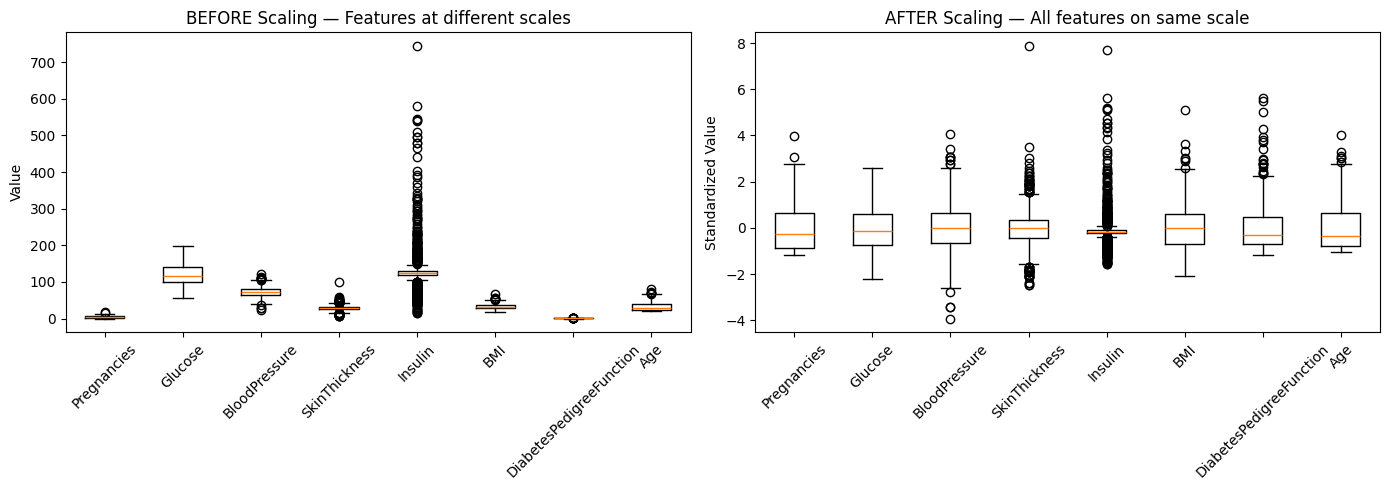

After scaling: all features are now on the same scale!
This prevents features with large values (like Insulin) from
dominating features with small values (like DiabetesPedigreeFunction)


In [9]:
# Let's visually prove that scaling worked
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling — raw data
axes[0].boxplot(X_train.fillna(X_train.median()).values,
                labels=X_train.columns, vert=True)
axes[0].set_title('BEFORE Scaling — Features at different scales')
axes[0].set_xticklabels(X_train.columns, rotation=45)
axes[0].set_ylabel('Value')

# After scaling — processed data
axes[1].boxplot(X_train_processed,
                labels=X_train.columns, vert=True)
axes[1].set_title('AFTER Scaling — All features on same scale')
axes[1].set_xticklabels(X_train.columns, rotation=45)
axes[1].set_ylabel('Standardized Value')

plt.tight_layout()
plt.show()

print("After scaling: all features are now on the same scale!")
print("This prevents features with large values (like Insulin) from")
print("dominating features with small values (like DiabetesPedigreeFunction)")

In [10]:
# Save the preprocessing pipeline to disk
# We save it separately from the model because:
# When a NEW user submits data through our web app,
# we must apply the EXACT same preprocessing before predicting
# If we don't, predictions will be completely wrong

os.makedirs('../models', exist_ok=True)

joblib.dump(preprocessing_pipeline, '../models/preprocessing_pipeline.joblib')

print("Pipeline saved to: models/preprocessing_pipeline.joblib")
print()
print("What joblib.dump does:")
print("  → Serializes the Python object into a binary file")
print("  → Can be loaded later with joblib.load()")
print("  → Preserves the exact median and scale values learned from training data")

Pipeline saved to: models/preprocessing_pipeline.joblib

What joblib.dump does:
  → Serializes the Python object into a binary file
  → Can be loaded later with joblib.load()
  → Preserves the exact median and scale values learned from training data


In [11]:
# Save processed arrays so Phase 4 can directly use them
np.save('../data/X_train.npy', X_train_processed)
np.save('../data/X_test.npy', X_test_processed)
np.save('../data/y_train.npy', y_train.values)
np.save('../data/y_test.npy', y_test.values)

print("Processed data saved:")
print("  → data/X_train.npy")
print("  → data/X_test.npy")
print("  → data/y_train.npy")
print("  → data/y_test.npy")
print()

# Final summary
print("=" * 50)
print("PHASE 3 COMPLETE — DATA IS READY FOR MODELING")
print("=" * 50)
print(f"Training samples : {X_train_processed.shape[0]}")
print(f"Testing samples  : {X_test_processed.shape[0]}")
print(f"Features         : {X_train_processed.shape[1]}")
print(f"Missing values   : FIXED (median imputation)")
print(f"Feature scaling  : DONE (StandardScaler)")
print(f"Pipeline saved   : models/preprocessing_pipeline.joblib")

Processed data saved:
  → data/X_train.npy
  → data/X_test.npy
  → data/y_train.npy
  → data/y_test.npy

PHASE 3 COMPLETE — DATA IS READY FOR MODELING
Training samples : 614
Testing samples  : 154
Features         : 8
Missing values   : FIXED (median imputation)
Feature scaling  : DONE (StandardScaler)
Pipeline saved   : models/preprocessing_pipeline.joblib
